# Stellar Luminosity

## Setup


In [1]:
# Install required libraries (run this once if needed)
%pip install numpy matplotlib

  Using cached numpy-2.5.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.11.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
  Using cached pillow-12.3.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached numpy-2.5.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.7 MB)
Using cached matplotlib-3.11.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (10.0 MB)
Using cached contourpy-1.3.

In the following we find our dataset, where mass is the stellar mass in units of solar mass and the luminosity is the stellar luminosity in units of solar luminosity.We vectorize it using the library numpy to do numerical computation.

In [35]:
import numpy as np
import matplotlib.pyplot as plt

mass_array = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
luminosity_array = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])

## Exploring the dataset

We can plot the mass-luminosity relationship to visualize the shape and range of the variables. We observe in the following function has a exponential shape, this leads us to think that using a linear model could be counterproductive, given that it might show systematic errors, especially,with masses greater than 1.50 because the relationship plots in a more exponential way.

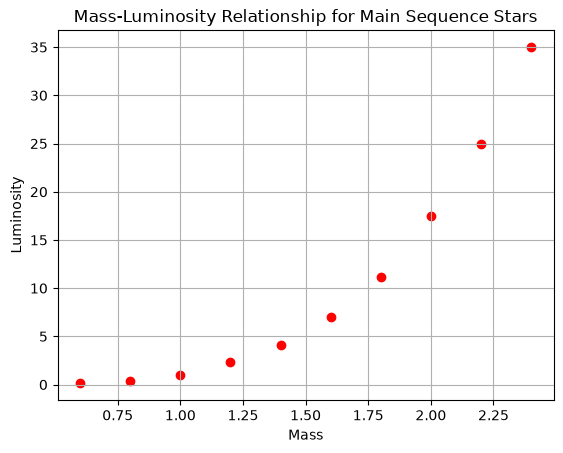

In [36]:
plt.scatter(mass_array,luminosity_array, color='r', label='Data Points')
plt.title('Mass-Luminosity Relationship for Main Sequence Stars')
plt.xlabel('Mass')
plt.ylabel('Luminosity')
plt.grid()

To reforce the hyphotesis of the shape of the relationship being plotted, we use a lynestyle to connect the dots:

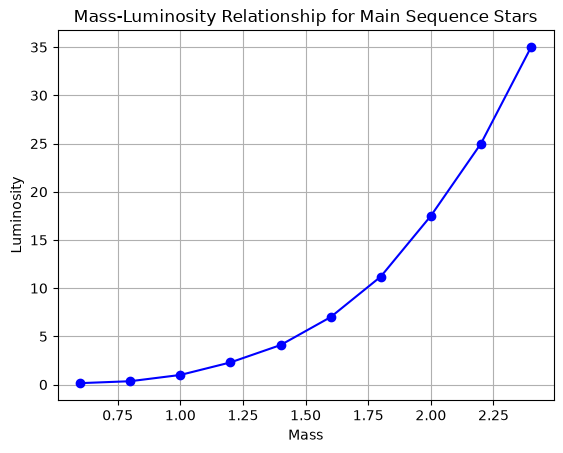

In [37]:
plt.plot(mass_array, luminosity_array, marker='o', linestyle='-', color='b')
plt.title('Mass-Luminosity Relationship for Main Sequence Stars')
plt.xlabel('Mass')
plt.ylabel('Luminosity')
plt.grid()

## Training Learn Functions

In [43]:
def predict(x, w, b):
    """Predict the output given the input, weights and bias."""
    return w * x + b

def compute_cost(x, y, w, b):
    """Compute the cost J(w,b) using NumPy vectorization."""
    m = x.shape[0]
    y_hat = predict(x, w, b)
    errors = y_hat - y
    cost = np.sum(errors ** 2) / (2 * m)
    return cost

def mean_squared_error(y_hat, y):
    """function to compute the mean squared error between predicted and actual values"""
    y_hat = np.array(y_hat, dtype=float)
    y = np.array(y, dtype=float)
    m = y.shape[0]
    return np.sum((y_hat - y) ** 2) / (2 * m)

def compute_gradients(x, y, w, b):
    """Compute dJ/dw and dJ/db using NumPy vectorization."""
    m = x.shape[0]
    y_hat = predict(x, w, b)
    errors = y_hat - y
    dj_dw = (x.T @ errors) / m
    dj_db = np.sum(errors) / m
    return dj_dw, dj_db

def gradient_descent(x, y, w_init, b_init, alpha, num_iterations):
    """Run gradient descent using vectorized cost and gradient computations."""
    w = w_init
    b = b_init
    history = []

    for i in range(num_iterations):
        dj_dw, dj_db = compute_gradients(x, y, w, b)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        cost = compute_cost(x, y, w, b)
        history.append((i, cost))

        if i % max(1, (num_iterations // 10)) == 0:
            print(f"Iteration {i:4d}: w={w:7.4f}, b={b:7.4f}, cost={cost:8.4f}")

    return w, b, history

def feature_scale(X):
    means = X.mean(axis=0)
    stds = X.std(axis=0, ddof=0)
    X_scaled = (X - means) / stds
    return X_scaled, means, stds

### Functions for more features

In [50]:
def build_polynomial_features(x, degree=2):
    x = np.asarray(x, dtype=float).reshape(-1, 1)
    features = []
    for d in range(1, degree + 1):
        features.append(x ** d)
    return np.column_stack(features)

def predict_poly(X, w, b):
    return X @ w + b

def compute_cost_poly(X, y, w, b):
    m = X.shape[0]
    y_hat = predict_poly(X, w, b)
    errors = y_hat - y
    return np.sum(errors**2) / (2 * m)

def compute_gradients_poly(X, y, w, b):
    m = X.shape[0]
    y_hat = predict_poly(X, w, b)
    errors = y_hat - y
    dj_dw = (X.T @ errors) / m
    dj_db = np.sum(errors) / m
    return dj_dw, dj_db

def gradient_descent_poly(X, y, w_init, b_init, alpha, num_iterations, print_progress=True):
    w = w_init.copy()
    b = b_init
    history_it = []
    history_cost = []

    for i in range(num_iterations):
        dj_dw, dj_db = compute_gradients_poly(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        cost = compute_cost_poly(X, y, w, b)
        history_it.append(i)
        history_cost.append(cost)

    return w, b, history_it, history_cost

## Linear Model Training

Below we follow the training procedure step by step:
1. Initialize the parameters.
2. Select a learning rate and the number of iterations.
3. Train the model with gradient descent.
4. Plot the cost over time.
5. Plot the fitted line against the observations.
6. Report the final parameters and cost.
7. Diagnose convergence and possible systematic errors.


Iteration    0: w= 0.2152, b= 0.1036, cost=112.0896
Iteration  100: w= 6.8004, b= 1.5699, cost= 31.9704
Iteration  200: w= 7.9674, b=-0.0073, cost= 28.0913
Iteration  300: w= 8.8900, b=-1.5257, cost= 24.9336
Iteration  400: w= 9.7253, b=-2.9093, cost= 22.3208
Iteration  500: w=10.4849, b=-4.1680, cost= 20.1590
Iteration  600: w=11.1759, b=-5.3129, cost= 18.3703
Iteration  700: w=11.8044, b=-6.3543, cost= 16.8903
Iteration  800: w=12.3762, b=-7.3015, cost= 15.6658
Iteration  900: w=12.8962, b=-8.1632, cost= 14.6525


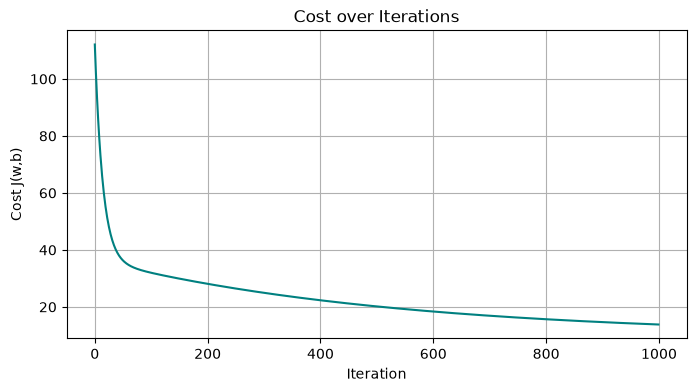

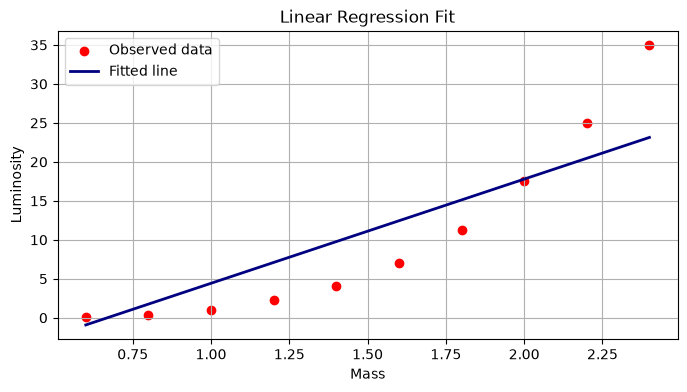

Final parameters: w = 13.364761, b = -8.939533
Final cost: 13.821822
Residuals:
[ -1.07067605   1.40227617   3.42522839   4.79818061   5.67113283
   5.44408505   3.91703727   0.28998949  -4.53705829 -11.86410607]


In [44]:
x_linear = np.array(mass_array)

w_init = 0.0
b_init = 0.0

alpha = 0.01
num_iterations = 1000

# Training
w_final, b_final, history = gradient_descent(
    x_linear,
    luminosity_array,
    w_init,
    b_init,
    alpha,
    num_iterations,
)

# Plotting
iterations = [i for i, _ in history]
costs = [c for _, c in history]

plt.figure(figsize=(8, 4))
plt.plot(iterations, costs, color='teal')
plt.title('Cost over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Cost J(w,b)')
plt.grid(True)
plt.show()

# Fitted line with the observations
x_fit = np.linspace(min(x_linear), max(x_linear), 200)
y_fit = predict(x_fit, w_final, b_final)

plt.figure(figsize=(8, 4))
plt.scatter(x_linear, luminosity_array, color='red', label='Observed data')
plt.plot(x_fit, y_fit, color='navy', linewidth=2, label='Fitted line')
plt.title('Linear Regression Fit')
plt.xlabel('Mass')
plt.ylabel('Luminosity')
plt.grid(True)
plt.legend()
plt.show()


final_cost = compute_cost(x_linear, luminosity_array, w_final, b_final)
print(f"Final parameters: w = {w_final:.6f}, b = {b_final:.6f}")
print(f"Final cost: {final_cost:.6f}")

# Convergence and systematic errors
predictions = predict(x_linear, w_final, b_final)
residuals = predictions - luminosity_array

print("Residuals:")
print(residuals)

As we can see, the fitted line has too many systemic errors when compared to the observed data, showing that a lineal model was not adequate.

## Polynominial Model Training

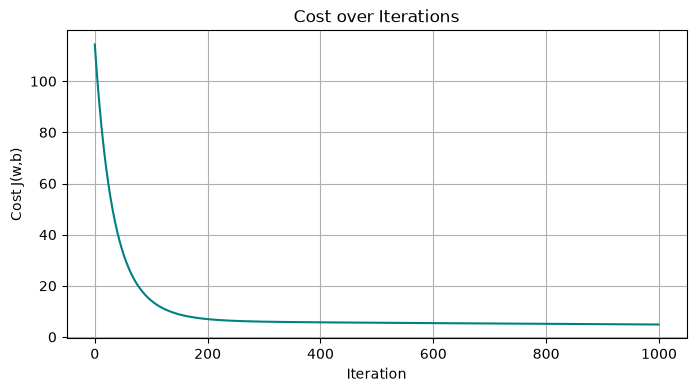

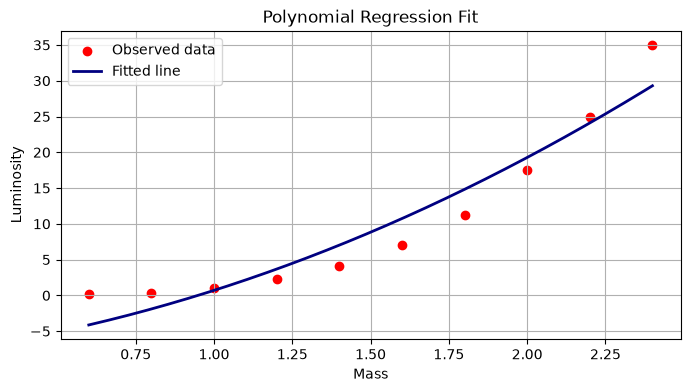

In [58]:
x_polynomial = np.column_stack([mass_array, mass_array ** 2])

degree = 2
x_polynomial_scaled, means_poly, stds_poly = feature_scale(x_polynomial)

w_init = np.zeros(x_polynomial_scaled.shape[1])
b_init = 0.0

w_final, b_final, history_it, history_cost = gradient_descent_poly(
    x_polynomial_scaled,
    luminosity_array,
    w_init,
    b_init,
    alpha,
    num_iterations,
    print_progress=False
)

iterations = history_it
costs = history_cost

plt.figure(figsize=(8, 4))
plt.plot(iterations, costs, color='teal')
plt.title('Cost over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Cost J(w,b)')
plt.grid(True)
plt.show()

# Fitting the polynomial regression model to the data
x_fit = np.linspace(np.min(mass_array), np.max(mass_array), 200)
x_fit_poly = build_polynomial_features(x_fit, degree=degree)

x_fit_poly_scaled = (x_fit_poly - means_poly) / stds_poly

y_fit = predict_poly(x_fit_poly_scaled, w_final, b_final)

plt.figure(figsize=(8, 4))
plt.scatter(mass_array, luminosity_array, color='red', label='Observed data')
plt.plot(x_fit, y_fit, color='navy', linewidth=2, label='Fitted line')
plt.title('Polynomial Regression Fit')
plt.xlabel('Mass')
plt.ylabel('Luminosity')
plt.grid(True)
plt.legend()
plt.show()

## Comparation of both models


## Testing of the predictions

## Reflections


What does this regression experiment reveal—and what does it fail to reveal—about how more advanced AI systems learn?

Do you think Artificial General Intelligence is achievable? Explain what you understand by AGI and why you believe it is—or is not—reachable.

Could AGI emerge primarily by scaling neural networks with more GPUs, data, and parameters? Or will it require fundamentally different architectures, learning mechanisms, theories, or ways of interacting with the world?

One question about AI-driven systems that I want to explore during the semester is: ______________________________